In [1]:
%load_ext autoreload
%autoreload 2

# Enable packages in project notebook (not required for .py scripts)
import sys
import os

# Add the project root or parent folder to sys.path
sys.path.append(os.path.abspath("../../")) 


import yaml
import pickle
from tqdm import tqdm

import numpy as np
import jax.numpy as jnp
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt
palette = sns.color_palette("Paired", 6)

import jax
import optax
import torch
import torch.utils.data as data

import counterfactual_alignment as cfa
from counterfactual_alignment import custom_datasets, custom_models, loss_functions, knowledge_functions
from counterfactual_alignment import utilities as ut

from counterfactual_alignment.pipeline import Pipeline




25-Sep-07 16:20:09 fatf.utils.array.tools INFO     Using numpy's numpy.lib.recfunctions.structured_to_unstructured as fatf.utils.array.tools.structured_to_unstructured and fatf.utils.array.tools.structured_to_unstructured_row.


In [2]:
"""
Gen Datasets
"""

"""
Initialise Parameters
"""

config_file = "config.yaml" #assuming local yaml file
with open(config_file,'r') as file:
    config = yaml.unsafe_load(file)

seed = seed=config['hyperparams']['seed']
key = jax.random.PRNGKey(seed)
noise_key,sample_key,model_key = jax.random.split(key,3)

def optimum_classifier(Z):
        """
        Inputs  | z:      x,y coordinates of data to be classified.
        Outputs | probs:  array of probabilities for each class for input data.
        """
        return np.array([int(z[0]>=0) for z in Z])


size = config['data_params']['train_size'] + config['data_params']['validation_size']

X_dims = 2
X = np.array([(x,x**2) for x in np.linspace(-1,1,size)]) + jax.random.normal(noise_key,(size,X_dims))*0.1 # multiply by scaling factor

Y = np.zeros_like(X[:,0])
Y[int(size/2 + size%2):] = 1

y_preds = optimum_classifier(X)

sample_indices = np.empty(0)
# sample training set
for i,_ in enumerate(list(set(Y))):
    #   sample_indices = np.concatenate((sample_indices,jax.random.randint(sample_key,tuple([int(config['data_params']['train_size']/2)]),np.ceil(i*size/2),np.floor((i+1)*size/2))))
    sample_indices = np.concatenate((sample_indices,jax.random.randint(sample_key,tuple([int(config['data_params']['train_size'])]),np.ceil(i*size/2),np.floor((i+1)*size/2))))

# sample_indices = jax.random.permutation(sample_key,size)[:config['data_params']['train_size']] 
print('sampleindices: ',sample_indices)

X_train_CE = np.array([X[int(i)] for i in sample_indices])
Y_train_CE = np.array([Y[int(i)] for i in sample_indices])


X_test = np.array([X[i] for i in range(size) if i not in sample_indices])
Y_test = np.array([Y[i] for i in range(size) if i not in sample_indices])

full_df = pd.DataFrame({'x_0':X[:,0],
                         'x_1':X[:,1],
                         'Class':Y})

train_df = pd.DataFrame({'x_0':X_train_CE[:,0],
                         'x_1':X_train_CE[:,1],
                         'Class':Y_train_CE})

test_df = pd.DataFrame({'x_0':X_test[:,0],
                         'x_1':X_test[:,1],
                         'Class':Y_test})


datasets = {'train' :data.TensorDataset(torch.tensor(X_train_CE),torch.tensor(Y_train_CE),torch.tensor(np.zeros_like(X_train_CE))),
            'test'  :data.TensorDataset(torch.tensor(X_test),torch.tensor(Y_test),torch.tensor(np.zeros_like(X_test)))}


sampleindices:  [ 92.  12.  69. 194. 114. 171.]


Add path of points between observation and counterfactual

In [3]:
n_samples = config['data_params']['n_vec']

# knowledge = knowledge_functions.counterfactual_vector_paths(X_train_CE,Y_train_CE,classifier=optimum_classifier,n_samples=n_samples)
knowledge = knowledge_functions.counterfactual_feasible_vector_paths(X_train_CE,Y_train_CE,classifier=optimum_classifier,n_samples=n_samples)


Generating 1 counterfactual samples per observation ...


0it [00:00, ?it/s]

generating : 0
generating : 1
generating : 2
generating : 3
generating : 4
generating : 5


In [4]:
X_train_CE

array([[-0.1494152 ,  0.03399225],
       [-0.78005415,  0.8168741 ],
       [-0.2723206 ,  0.2969459 ],
       [ 0.7373153 ,  0.7802789 ],
       [ 0.15369308,  0.21431924],
       [ 0.7671744 ,  0.55082667]], dtype=float32)

In [14]:
knowledge['origin'].reshape(6,2)

array([[-0.06473467,  0.00419058],
       [-0.38005415,  0.14444116],
       [-0.12618738,  0.01592325],
       [ 0.32863057,  0.10799805],
       [ 0.03681946,  0.00135567],
       [ 0.34356014,  0.11803357]])

In [12]:
int(n_samples*config['data_params']['train_size']*2),X_dims

(6, 2)

In [16]:

X_train_D = knowledge['origin'].reshape(int(n_samples*config['data_params']['train_size']*2),X_dims)
Y_train_D = np.array([[y]*n_samples for y in Y_train_CE]).reshape(int(n_samples*config['data_params']['train_size']*2))

K_df = pd.DataFrame({'x_0':X_train_D[:,0],
                      'x_1':X_train_D[:,1],
                      'Class':Y_train_D})

# 

k_dim = np.shape(knowledge['origin'])

K_train_D = np.vstack([
    knowledge['vector'][i] for i in range(k_dim[0]) for _ in range(k_dim[1])
])


batch = {'train':{
            'original':{
                'X':X_train_CE,
                'Y':Y_train_CE
            },
            'additional':{
                'X':X_train_D,
                'Y':Y_train_D,
                'K':K_train_D
            }},
         'test':{
             'X':X_test,
             'Y':Y_test
         }}



### Visualise

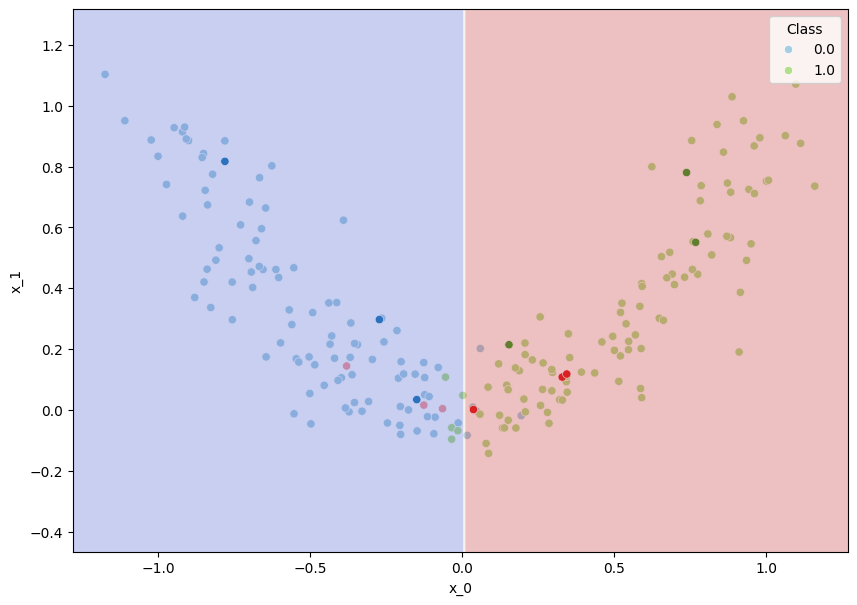

In [17]:

# if config['visualisation']['visualise']:
# #     fulldata_scatter = sns.scatterplot(data=full_df,x='x_0',y='x_1',hue='Class',palette=[palette[0],palette[2]],alpha=0.5,s=5,legend=False)
#     test_scatter = sns.scatterplot(data=test_df,x='x_0',y='x_1',hue='Class',palette=[palette[0],palette[2]])
#     K_scatter = sns.scatterplot(data=K_df,x='x_0',y='x_1',hue='Class',palette=[palette[4],palette[5]],legend=False)
#     train_scatter = sns.scatterplot(data=train_df,x='x_0',y='x_1',hue='Class',palette=[palette[1],palette[3]],legend=False)

if config['visualisation']['visualise']:

    fig, ax = plt.subplots(figsize=(10, 10))
    


    # Scatterplots on shared axis
    sns.scatterplot(data=test_df, x='x_0', y='x_1', hue='Class', palette=[palette[0], palette[2]], ax=ax)
    sns.scatterplot(data=K_df, x='x_0', y='x_1', hue='Class', palette=[palette[4], palette[5]], legend=False, ax=ax)
    sns.scatterplot(data=train_df, x='x_0', y='x_1', hue='Class', palette=[palette[1], palette[3]], legend=False, ax=ax)

    # Compute plot limits
    margin = 0.5  # Adjustable margin around data
    x_min = X_train_CE[:, 0].min() - margin
    x_max = X_train_CE[:, 0].max() + margin
    y_min = X_train_CE[:, 1].min() - margin
    y_max = X_train_CE[:, 1].max() + margin

    # Grid resolution
    grid_points = 200  # Higher for smoother contours
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_points),
        np.linspace(y_min, y_max, grid_points)
    )

    # Classifier output
    Z = optimum_classifier(np.stack([xx.ravel(), yy.ravel()]).T)
    Z_r = Z.reshape(xx.shape)

    # Contour overlay
    contour = ax.contourf(xx, yy, Z_r, levels=10, alpha=0.3, cmap='coolwarm')

    # Explicit, matching plot limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal')  # Optional for geometric consistency

    plt.show()


### Method 1
baseline

In [19]:
batch

{'train': {'original': {'X': array([[-0.1494152 ,  0.03399225],
          [-0.78005415,  0.8168741 ],
          [-0.2723206 ,  0.2969459 ],
          [ 0.7373153 ,  0.7802789 ],
          [ 0.15369308,  0.21431924],
          [ 0.7671744 ,  0.55082667]], dtype=float32),
   'Y': array([0., 0., 0., 1., 1., 1.], dtype=float32)},
  'additional': {'X': array([[-0.06473467,  0.00419058],
          [-0.38005415,  0.14444116],
          [-0.12618738,  0.01592325],
          [ 0.32863057,  0.10799805],
          [ 0.03681946,  0.00135567],
          [ 0.34356014,  0.11803357]]),
   'Y': array([0., 0., 0., 1., 1., 1.], dtype=float32),
   'K': array([[ 1.,  0.],
          [ 1.,  0.],
          [ 1.,  0.],
          [-1.,  0.],
          [-1.,  0.],
          [-1.,  0.]])}},
 'test': {'X': array([[-9.46806252e-01,  9.27698314e-01],
         [-8.99373293e-01,  8.85250807e-01],
         [-1.17393875e+00,  1.10307264e+00],
         [-9.19439971e-01,  9.13963974e-01],
         [-9.07000303e-01,  8.907

In [21]:
config['hyperparams']['loss_function'] = 'combined_loss'
config['hyperparams']['loss_mix'] = 0.0

pipeline = Pipeline(batch,data_description="",method_description="baseline",overwrite=True, config = config)

pipeline.run(n_epochs=config['hyperparams']['epochs'])
baseline_name = pipeline.output_name

res = []
for output_name in [pipeline.output_name]:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))


res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline',"With K"])



Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_32__DATA___SIZE_3__LOSS_combined_loss__ALPHA_0.0__METHOD_baseline


  0%|          | 0/10 [00:00<?, ?it/s]


KeyError: 'K'

Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.5__METHOD_mixed


100%|██████████| 20/20 [00:00<00:00, 26.42it/s]


Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.5__METHOD_mixed. Trained for 20 epochs.


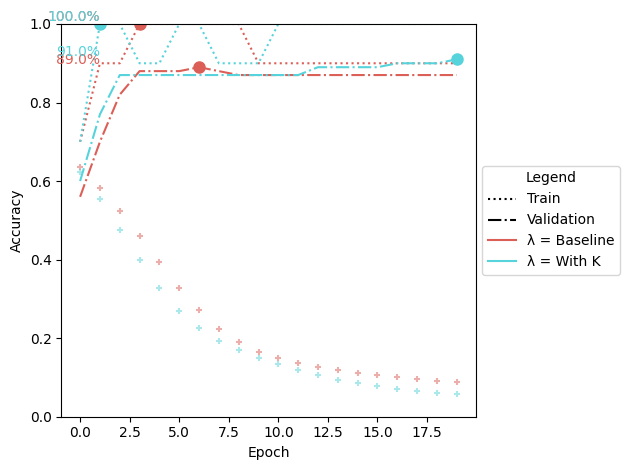

In [ ]:

config['hyperparams']['loss_mix'] = 0.5

pipeline = Pipeline(batch,config = config,data_description="",method_description="mixed",overwrite=True)
pipeline.run(n_epochs=config['hyperparams']['epochs'])

res = []
for output_name in [baseline_name,pipeline.output_name]:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))

res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline',"With K"])

Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_1.0__METHOD_mixed


100%|██████████| 20/20 [00:00<00:00, 28.13it/s]


Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_1.0__METHOD_mixed. Trained for 20 epochs.


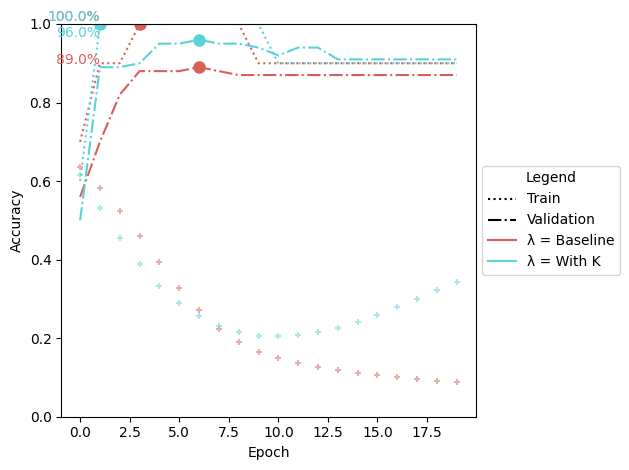

In [ ]:
config['hyperparams']['loss_mix'] = 1.0

pipeline = Pipeline(batch,config = config,data_description="",method_description="mixed",overwrite=True)
pipeline.run(n_epochs=config['hyperparams']['epochs'])

res = []
for output_name in [baseline_name,pipeline.output_name]:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))


res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline',"With K"])

Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.0__METHOD_feasible_path


100%|██████████| 20/20 [00:00<00:00, 26.51it/s]


Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.0__METHOD_feasible_path. Trained for 20 epochs.
Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.125__METHOD_feasible_path


100%|██████████| 20/20 [00:00<00:00, 27.08it/s]


Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.125__METHOD_feasible_path. Trained for 20 epochs.
Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.25__METHOD_feasible_path


...

Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.75__METHOD_feasible_path. Trained for 20 epochs.
Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.875__METHOD_feasible_path


100%|██████████| 20/20 [00:00<00:00, 27.51it/s]


Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_0.875__METHOD_feasible_path. Trained for 20 epochs.
Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_1.0__METHOD_feasible_path


100%|██████████| 20/20 [00:00<00:00, 27.98it/s]


Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.1__BATCHSIZE_8__DATA___SIZE_10__LOSS_combined_loss__ALPHA_1.0__METHOD_feasible_path. Trained for 20 epochs.


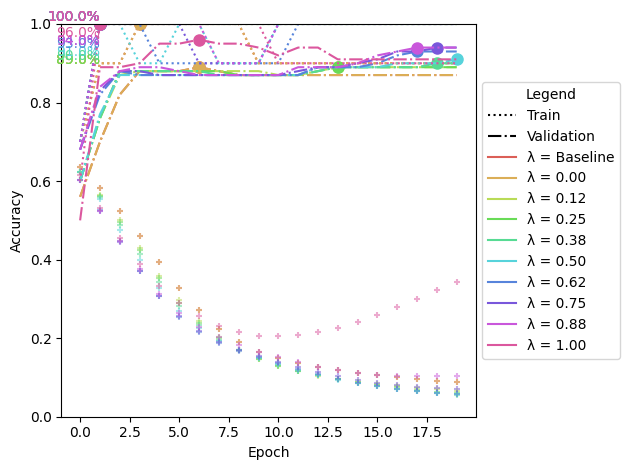

In [ ]:
output_names = [baseline_name]

for mix_rate in np.linspace(0,1,9):
    config['hyperparams']['loss_mix'] = mix_rate

    pipeline = Pipeline(batch,config = config,data_description="",method_description="feasible_path",overwrite=True)
    pipeline.run(n_epochs=config['hyperparams']['epochs'])
    output_names.append(pipeline.output_name)


res = []
for output_name in output_names:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))

res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline']+[f"{n:.2f}"for n in np.linspace(0,1,9)])